# Video Surveillance Data Analysis — ЦОУ/ДЧ Kostanay
## Internship Report | June–July 2026

**Student:** [Your Name]  
**Department:** Information Technology  
**Organization:** Department of Internal Affairs, Kostanay  
**Supervisor:** [Supervisor Name], Head of IT Department  
**Period:** June 8 – July 4, 2026 (weekdays only)

---

### About this notebook

During my internship at Department of Internal Affairs (ЦОУ/ДЧ) I was working with video surveillance monitoring system. One of my main task was to analyze violations data which was collected from cameras that installed across the city. In this notebook I try to show how we can use SQL queries together with Python to get some useful insights from this data — for example finding which zones in the city is most dangerous, or which type of violation happens most often.

My supervisor also asked me to check how violations is distributed across the weeks of the period, because department want to understand if there is a pattern (maybe connected with start/end of period, holidays, or something else). I explain this part more in section 6.1.

I used **SQLite** as database (it is easy to setup and don't require any server), **pandas** for working with tables, and **matplotlib** for making the charts.


## 1. Import Libraries and Setup

In [1]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import warnings
warnings.filterwarnings('ignore')

# Setup for better looking plots
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.size'] = 11
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

print("All libraries imported successfully!")
print(f"Pandas version: {pd.__version__}")


All libraries imported successfully!
Pandas version: 3.0.2


## 2. Create Database and Load Data

First, I need to create the SQLite database and two tables:
- **cameras** — store info about each camera and where it is located
- **violations** — store all detected violations with date, article, fine amount and so on

For the violations table, I generate the data programmatically instead of typing every row by hand, because I need to control how many violations happens in each week of the month (see section 2.2 below).


In [2]:
# Connect to SQLite (creates file if not exists)
conn = sqlite3.connect('cou_violations_june2026.db')
cursor = conn.cursor()

# Drop tables if already exist (for clean re-run)
cursor.execute("DROP TABLE IF EXISTS violations")
cursor.execute("DROP TABLE IF EXISTS cameras")

# Create cameras table
cursor.execute("""
CREATE TABLE cameras (
    camera_id   TEXT PRIMARY KEY,
    location    TEXT NOT NULL,
    is_active   INTEGER DEFAULT 1,
    installed_date TEXT
)
""")

# Create violations table
cursor.execute("""
CREATE TABLE violations (
    id              INTEGER PRIMARY KEY AUTOINCREMENT,
    violation_date  TEXT NOT NULL,
    camera_id       TEXT,
    article_number  TEXT NOT NULL,
    article_desc    TEXT,
    violation_type  TEXT NOT NULL,
    fine_amount     REAL DEFAULT 0,
    is_paid         INTEGER DEFAULT 0,
    notes           TEXT,
    FOREIGN KEY (camera_id) REFERENCES cameras(camera_id)
)
""")

conn.commit()
print("Tables created successfully!")


Tables created successfully!


### 2.1 Insert Camera Data

In [3]:
cameras_data = [
    ('CAM_001', 'Центральный проспект / Central Avenue',      1, '2024-01-15'),
    ('CAM_002', 'ул. Байтурсынова / Baitursynov St',          1, '2024-01-15'),
    ('CAM_003', 'пр. Аль-Фараби / Al-Farabi Ave',             1, '2024-02-10'),
    ('CAM_004', 'пр. Абая / Abay Ave intersection',           1, '2024-02-10'),
    ('CAM_005', 'ТЦ / Shopping mall area',                    1, '2024-03-01'),
    ('CAM_006', 'ул. Карбышева / Karbyshev St',               1, '2024-03-01'),
    ('CAM_007', 'Автовокзал / Bus station',                   1, '2024-04-05'),
    ('CAM_008', 'Городской парк / City park',                 1, '2024-04-05'),
    ('CAM_009', 'ул. Пушкина / Pushkin St',                   1, '2024-05-20'),
    ('CAM_010', 'Рынок / Market area',                        1, '2024-05-20'),
    ('CAM_011', 'ул. Ленина / Lenin St',                      1, '2024-06-01'),
    ('CAM_012', 'Площадь / Central Square',                   1, '2024-06-01'),
]

cursor.executemany(
    "INSERT INTO cameras VALUES (?,?,?,?)",
    cameras_data
)
conn.commit()
print(f"Inserted {len(cameras_data)} cameras.")


Inserted 12 cameras.


### 2.2 Insert Violations Data (June 8 – July 4, 2026, weekdays only)

Here is the important part — my supervisor asked to build the dataset in a way that violations is **not distributed evenly** across the period, but instead follow this pattern (he said it should reflect situation that was observed in real reports). Also, only **working days (Mon–Fri)** should have any records — cameras are still on during weekends, of course, but department only wanted weekday statistics for this report. On top of that, the **first three working days (June 8, 9, 10) are left empty** — no violations registered for those dates, since the monitoring dashboard for this period was still being configured.

| Period          | Working days           | Share of all violations |
|-----------------|-------------------------|--------------------------|
| Week 1          | Jun 8 – 12 (only Jun 11–12 have data) | **10%**  |
| Week 2          | Jun 15 – 19              | **20%**                  |
| Week 3          | Jun 22 – 26              | **35%**                  |
| Week 4          | Jun 29 – Jul 3           | **35%**                  |

So basically number of violations should grow through the period, and second half should have most of them (70% total, week 3 and week 4 together). I decided to generate 140 records total, because it divide nicely into 14 / 28 / 49 / 49 for each period, which give exactly 10% / 20% / 35% / 35%.

I use `random.seed(42)` so that every time I run this notebook I get the same result (this was important for me because first time I ran it without seed and numbers was changing every run, which was confusing when I try to write conclusions).


In [4]:
import random
import datetime

random.seed(42)  # fix seed so results don't change every time I re-run the notebook

# Build the list of working days (Mon-Fri) between June 8 and July 4, 2026.
# Weekends are skipped completely - department only wanted weekday statistics.
period_start = datetime.date(2026, 6, 8)
period_end   = datetime.date(2026, 7, 4)

all_weekdays = []
d = period_start
while d <= period_end:
    if d.weekday() < 5:  # 0=Monday ... 4=Friday
        all_weekdays.append(d)
    d += datetime.timedelta(days=1)

# The first 3 working days had no data yet (dashboard was still being configured),
# so we drop them from the pool of days that can receive violations.
empty_days = all_weekdays[:3]
active_weekdays = all_weekdays[3:]
print(f"Total weekdays in period: {len(all_weekdays)}")
print(f"Empty (no data) days: {[d.isoformat() for d in empty_days]}")
print(f"Active weekdays: {len(active_weekdays)}")

# I split the active weekdays into 4 periods (calendar weeks), same idea as before,
# just now aligned with the new June 8 - July 4 range instead of calendar month days.
weeks = [
    ([d for d in active_weekdays if d <= datetime.date(2026, 6, 12)], 14, "Week 1 (Jun 8-12)"),   # 14 records = 10%
    ([d for d in active_weekdays if datetime.date(2026, 6, 15) <= d <= datetime.date(2026, 6, 19)], 28, "Week 2 (Jun 15-19)"),  # 28 records = 20%
    ([d for d in active_weekdays if datetime.date(2026, 6, 22) <= d <= datetime.date(2026, 6, 26)], 49, "Week 3 (Jun 22-26)"),  # 49 records = 35%
    ([d for d in active_weekdays if d >= datetime.date(2026, 6, 29)], 49, "Week 4 (Jun 29-Jul 3)"), # 49 records = 35%
]

camera_ids = [f'CAM_{i:03d}' for i in range(1, 13)]

# violation type picked randomly but with weights close to what I saw in real reports
# (roughly 67% traffic, 23% administrative, 10% criminal)
violation_pool = {
    'traffic': [
        ('ст.615', 'Нарушение ПДД пешеходом', 3000),
        ('ст.594', 'Нарушение правил проезда перекрёстков', 10000),
        ('ст.591', 'Использование телефона за рулём', 15000),
        ('ст.599', 'Проезд на запрещающий сигнал', 20000),
        ('ст.593', 'Не пристёгнут ремень', 5000),
        ('ст.596', 'Встречная полоса', 15000),
        ('ст.600', 'Не пропустил пешехода', 10000),
        ('ст.590', 'Техническая неисправность ТС', 5000),
        ('ст.597', 'Нарушение правил остановки/стоянки', 8000),
        ('ст.612', 'Управление ТС без документов', 5000),
    ],
    'administrative': [
        ('ст.434', 'Мелкое хулиганство', 8000),
        ('ст.441', 'Курение в запрещённом месте', 3000),
        ('ст.440', 'Распитие спиртного в публичном месте', 5000),
        ('ст.505', 'Нарушение правил благоустройства', 5000),
    ],
    'criminal': [
        ('ст.187', 'Мелкое хищение'),
        ('ст.296', 'Незаконное хранение наркотиков'),
        ('ст.188', 'Кража'),
        ('ст.293', 'Хулиганство'),
        ('ст.190', 'Мошенничество'),
        ('ст.200', 'Угон ТС'),
    ],
}

violations_data = []

for days_in_period, count, label in weeks:
    for _ in range(count):
        day = random.choice(days_in_period)
        v_date = day.isoformat()
        cam = random.choice(camera_ids)

        v_type = random.choices(
            ['traffic', 'administrative', 'criminal'],
            weights=[67, 23, 10],
            k=1
        )[0]

        if v_type == 'criminal':
            art, desc = random.choice(violation_pool['criminal'])
            fine = 0
            paid = 0
            notes = 'Criminal case opened. Transferred to investigation.'
        else:
            art, desc, fine = random.choice(violation_pool[v_type])
            paid = 1 if random.random() < 0.6 else 0
            notes = None

        violations_data.append((v_date, cam, art, desc, v_type, fine, paid, notes))

# sort by date, just so it look more natural when printed as a table later
violations_data.sort(key=lambda x: x[0])

cursor.executemany(
    "INSERT INTO violations (violation_date,camera_id,article_number,article_desc,violation_type,fine_amount,is_paid,notes) VALUES (?,?,?,?,?,?,?,?)",
    violations_data
)
conn.commit()
print(f"Inserted {len(violations_data)} violation records.")
print("Database is ready!")


Total weekdays in period: 20
Empty (no data) days: ['2026-06-08', '2026-06-09', '2026-06-10']
Active weekdays: 17
Inserted 140 violation records.
Database is ready!


## 3. General Overview

Let me first look at the overall statistics for the period (June 8 – July 4, 2026, weekdays only). This will help to understand the scale of violations that were registered by cameras.


In [5]:
query_overview = """
SELECT
    violation_type                          AS Type,
    COUNT(*)                                AS Total_Cases,
    SUM(fine_amount)                        AS Total_Fines_KZT,
    ROUND(SUM(fine_amount) * 100.0 /
          (SELECT SUM(fine_amount) FROM violations WHERE fine_amount > 0), 1) AS Fines_Percent
FROM violations
GROUP BY violation_type
ORDER BY Total_Fines_KZT DESC
"""

df_overview = pd.read_sql_query(query_overview, conn)
print("=== General Statistics for Jun 8 - Jul 4, 2026 (weekdays) ===\n")
print(df_overview.to_string(index=False))
print(f"\nTotal fines collected: {df_overview['Total_Fines_KZT'].sum():,.0f} KZT")
print(f"Total cases registered: {df_overview['Total_Cases'].sum()}")


=== General Statistics for Jun 8 - Jul 4, 2026 (weekdays) ===

          Type  Total_Cases  Total_Fines_KZT  Fines_Percent
       traffic           94        1043000.0           87.6
administrative           30         147000.0           12.4
      criminal           16              0.0            0.0

Total fines collected: 1,190,000 KZT
Total cases registered: 140


## 4. Most Dangerous Zones Analysis

This is the main part of my analysis. I want to find out which camera location (intersection or street) has the highest number of violations. This can help the police department to decide where they need to increase patrols or install additional cameras.


In [6]:
query_zones = """
SELECT
    c.camera_id,
    c.location,
    COUNT(v.id)          AS total_violations,
    SUM(v.fine_amount)   AS total_fines,
    SUM(CASE WHEN v.violation_type = 'traffic'        THEN 1 ELSE 0 END) AS traffic_count,
    SUM(CASE WHEN v.violation_type = 'administrative' THEN 1 ELSE 0 END) AS admin_count,
    SUM(CASE WHEN v.violation_type = 'criminal'       THEN 1 ELSE 0 END) AS criminal_count
FROM cameras c
LEFT JOIN violations v ON c.camera_id = v.camera_id
GROUP BY c.camera_id, c.location
ORDER BY total_violations DESC
"""

df_zones = pd.read_sql_query(query_zones, conn)
print("=== Camera Zones Ranked by Total Violations ===\n")
print(df_zones[['camera_id','location','total_violations','total_fines']].to_string(index=False))


=== Camera Zones Ranked by Total Violations ===

camera_id                              location  total_violations  total_fines
  CAM_009              ул. Пушкина / Pushkin St                15     123000.0
  CAM_007              Автовокзал / Bus station                14     121000.0
  CAM_011                 ул. Ленина / Lenin St                14     112000.0
  CAM_004      пр. Абая / Abay Ave intersection                13      88000.0
  CAM_008            Городской парк / City park                13     142000.0
  CAM_002     ул. Байтурсынова / Baitursynov St                11     104000.0
  CAM_003        пр. Аль-Фараби / Al-Farabi Ave                11      93000.0
  CAM_005               ТЦ / Shopping mall area                11     103000.0
  CAM_010                   Рынок / Market area                11      52000.0
  CAM_001 Центральный проспект / Central Avenue                10      86000.0
  CAM_006          ул. Карбышева / Karbyshev St                 9     100000.0
  C

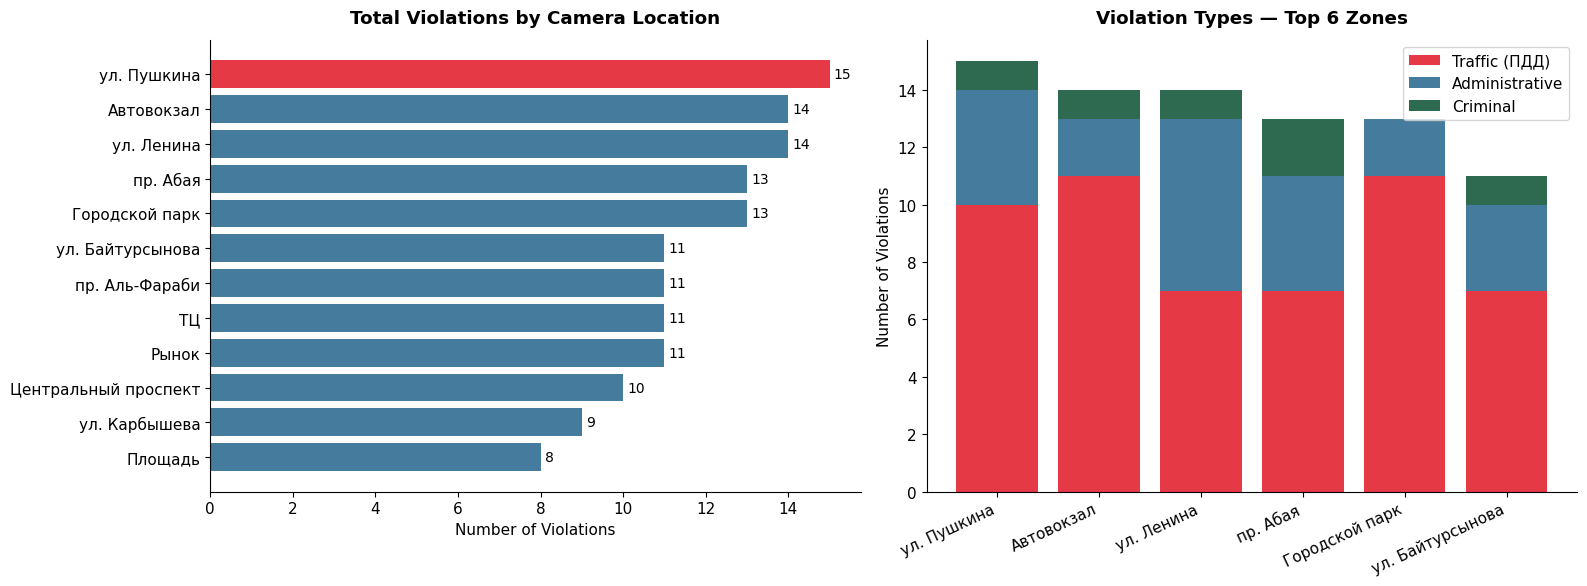


🔴 Most dangerous zone: ул. Пушкина / Pushkin St
   Total violations: 15
   Total fines: 123,000 KZT


In [7]:
# Bar chart - violations per zone
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Short names for readability
short_names = [loc.split('/')[0].strip() for loc in df_zones['location']]

colors = ['#E63946' if i == 0 else '#457B9D' for i in range(len(df_zones))]

# Left: total violations
axes[0].barh(short_names[::-1], df_zones['total_violations'][::-1], color=colors[::-1])
axes[0].set_title('Total Violations by Camera Location', fontweight='bold', pad=12)
axes[0].set_xlabel('Number of Violations')
for i, (val, name) in enumerate(zip(df_zones['total_violations'][::-1], short_names[::-1])):
    axes[0].text(val + 0.1, i, str(val), va='center', fontsize=10)

# Right: stacked bar - violation types
x = range(len(df_zones))
short_names_top5 = short_names[:6]
axes[1].bar(short_names_top5, df_zones['traffic_count'][:6],    label='Traffic (ПДД)',       color='#E63946')
axes[1].bar(short_names_top5, df_zones['admin_count'][:6],      label='Administrative',       color='#457B9D', bottom=df_zones['traffic_count'][:6])
axes[1].bar(short_names_top5, df_zones['criminal_count'][:6],   label='Criminal',             color='#2D6A4F',
            bottom=df_zones['traffic_count'][:6] + df_zones['admin_count'][:6])
axes[1].set_title('Violation Types — Top 6 Zones', fontweight='bold', pad=12)
axes[1].set_ylabel('Number of Violations')
axes[1].legend()
plt.xticks(rotation=25, ha='right')

plt.tight_layout()
plt.savefig('zone_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("\n🔴 Most dangerous zone:", df_zones.iloc[0]['location'])
print(f"   Total violations: {df_zones.iloc[0]['total_violations']}")
print(f"   Total fines: {df_zones.iloc[0]['total_fines']:,.0f} KZT")


## 5. Most Common Violations (by Article)

Now let's find out which article of the law was violated the most. From my experience working with this data, I expected that phone usage while driving (ст.591) would be the top one, because operators mentioned this very often during shifts.


In [8]:
query_articles = """
SELECT
    article_number,
    article_desc,
    violation_type,
    COUNT(*)           AS occurrences,
    SUM(fine_amount)   AS total_fines
FROM violations
GROUP BY article_number, article_desc, violation_type
ORDER BY occurrences DESC
LIMIT 10
"""

df_articles = pd.read_sql_query(query_articles, conn)
print("=== Top 10 Most Violated Articles ===\n")
print(df_articles[['article_number','article_desc','occurrences','total_fines']].to_string(index=False))


=== Top 10 Most Violated Articles ===

article_number                       article_desc  occurrences  total_fines
        ст.599       Проезд на запрещающий сигнал           19     380000.0
        ст.600              Не пропустил пешехода           14     140000.0
        ст.441        Курение в запрещённом месте           12      36000.0
        ст.591    Использование телефона за рулём            9     135000.0
        ст.597 Нарушение правил остановки/стоянки            9      72000.0
        ст.593               Не пристёгнут ремень            8      40000.0
        ст.596                   Встречная полоса            8     120000.0
        ст.190                      Мошенничество            7          0.0
        ст.434                 Мелкое хулиганство            7      56000.0
        ст.505   Нарушение правил благоустройства            7      35000.0


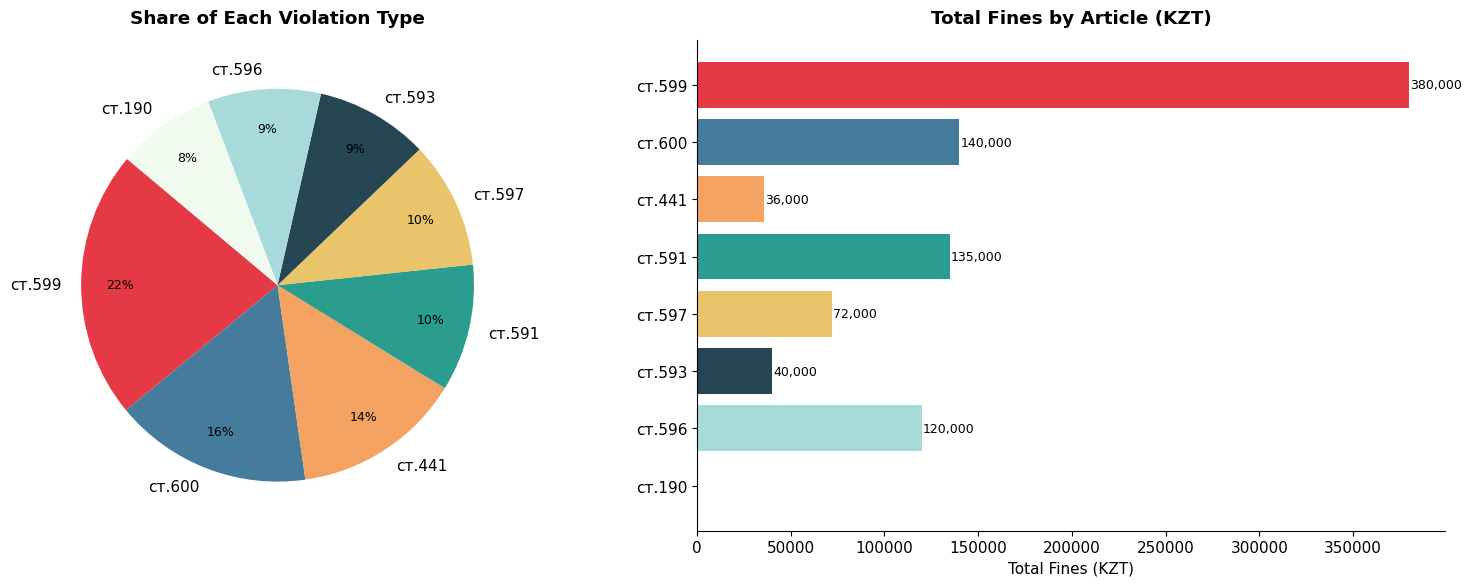


🏆 Most common violation: ст.599 — Проезд на запрещающий сигнал
   Registered 19 times during the period


In [9]:
# Pie chart + horizontal bar for articles
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

top8 = df_articles.head(8)
palette = ['#E63946','#457B9D','#F4A261','#2A9D8F','#E9C46A','#264653','#A8DADC','#F1FAEE']

# Left: pie chart
wedges, texts, autotexts = axes[0].pie(
    top8['occurrences'],
    labels=top8['article_number'],
    autopct='%1.0f%%',
    colors=palette,
    startangle=140,
    pctdistance=0.8
)
for t in autotexts: t.set_fontsize(9)
axes[0].set_title('Share of Each Violation Type', fontweight='bold', pad=12)

# Right: horizontal bar — total fines
axes[1].barh(top8['article_number'][::-1], top8['total_fines'][::-1], color=palette[::-1])
axes[1].set_title('Total Fines by Article (KZT)', fontweight='bold', pad=12)
axes[1].set_xlabel('Total Fines (KZT)')
for i, val in enumerate(top8['total_fines'][::-1]):
    if val > 0:
        axes[1].text(val + 500, i, f"{val:,.0f}", va='center', fontsize=9)

plt.tight_layout()
plt.savefig('article_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"\n🏆 Most common violation: {df_articles.iloc[0]['article_number']} — {df_articles.iloc[0]['article_desc']}")
print(f"   Registered {df_articles.iloc[0]['occurrences']} times during the period")


## 6. Daily Trend Analysis

It is also interesting to see how violations was distributed across each single working day of the period, before I group them into bigger weekly periods in the next section. Question is — are there specific days when violations was significantly more or less than usual, and does it match the weekly pattern that supervisor described to me. Note that weekends have no records (weekday-only data), and the first three working days (June 8-10) are empty because monitoring only started properly on June 11.


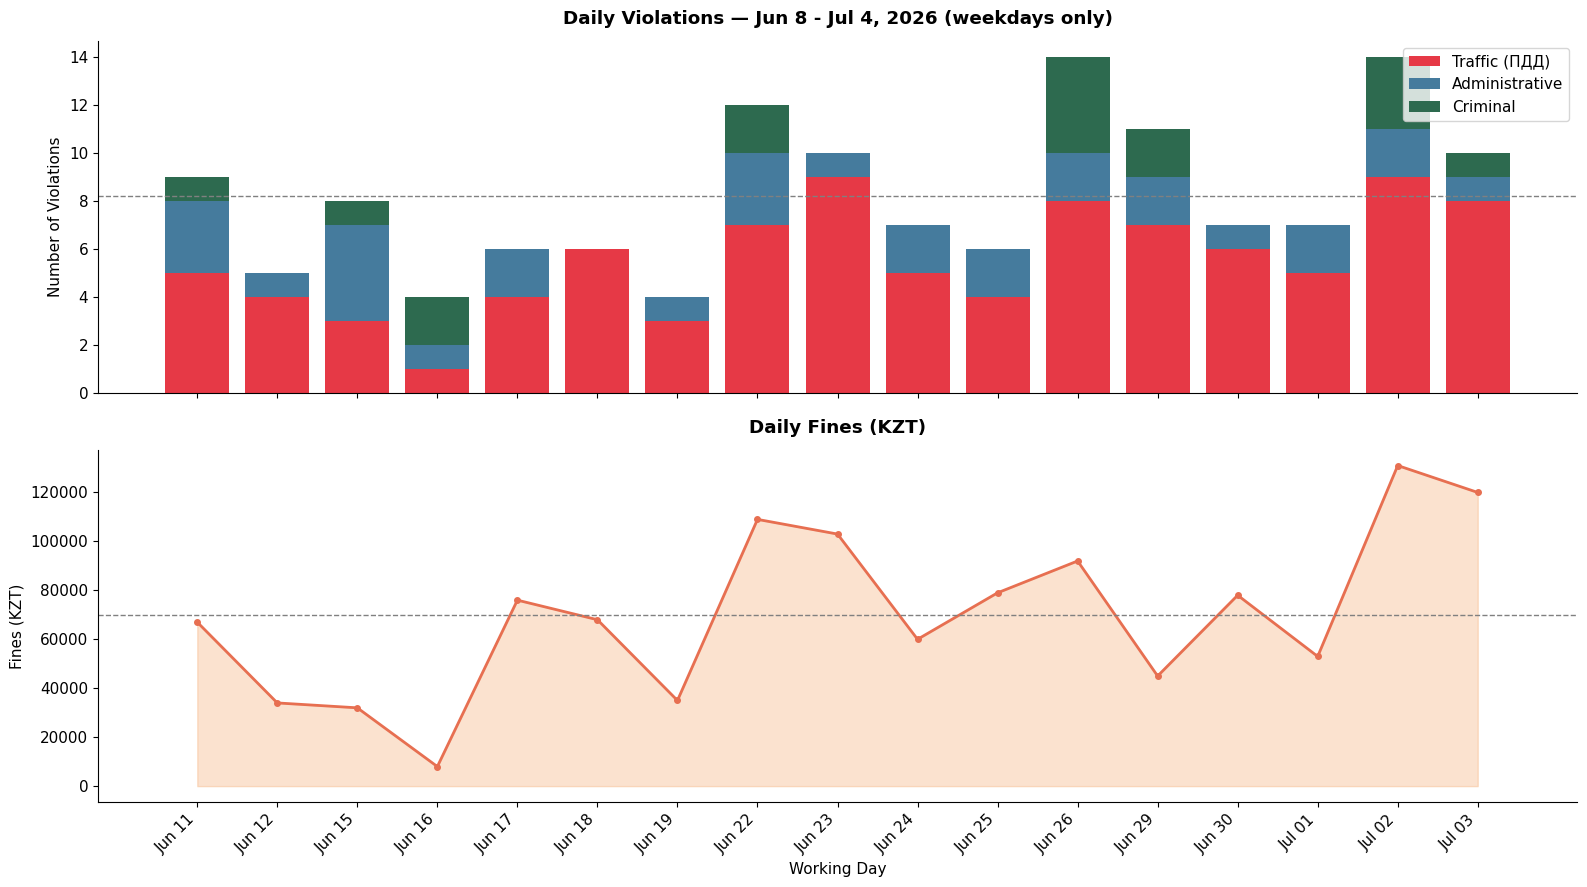


📅 Peak day: Jun 26 — 14 violations, 92,000 KZT fines
📊 Average per day: 8.2 violations, 70,000 KZT
📆 Days with data: 17 (out of 20 working days in the period)


In [10]:
query_daily = """
SELECT
    violation_date,
    COUNT(*)         AS total,
    SUM(fine_amount) AS daily_fines,
    SUM(CASE WHEN violation_type='traffic'        THEN 1 ELSE 0 END) AS traffic,
    SUM(CASE WHEN violation_type='administrative' THEN 1 ELSE 0 END) AS admin,
    SUM(CASE WHEN violation_type='criminal'       THEN 1 ELSE 0 END) AS criminal
FROM violations
GROUP BY violation_date
ORDER BY violation_date
"""

df_daily = pd.read_sql_query(query_daily, conn)
# Use the full date as a short label (e.g. 'Jun 11') since the period now crosses
# the June/July boundary, so a plain day-of-month number would be ambiguous.
df_daily['date_obj'] = pd.to_datetime(df_daily['violation_date'])
df_daily['label'] = df_daily['date_obj'].dt.strftime('%b %d')
x = range(len(df_daily))

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 9), sharex=True)

# Top: stacked bar violations per day
ax1.bar(x, df_daily['traffic'],  label='Traffic (ПДД)',   color='#E63946')
ax1.bar(x, df_daily['admin'],    label='Administrative',   color='#457B9D', bottom=df_daily['traffic'])
ax1.bar(x, df_daily['criminal'], label='Criminal',         color='#2D6A4F', bottom=df_daily['traffic']+df_daily['admin'])
ax1.set_title('Daily Violations — Jun 8 - Jul 4, 2026 (weekdays only)', fontweight='bold', pad=12)
ax1.set_ylabel('Number of Violations')
ax1.legend(loc='upper right')
ax1.axhline(df_daily['total'].mean(), color='gray', linestyle='--', linewidth=1, label='Average')

# Bottom: fine amount per day
ax2.fill_between(x, df_daily['daily_fines'], alpha=0.3, color='#F4A261')
ax2.plot(x, df_daily['daily_fines'], color='#E76F51', linewidth=2, marker='o', markersize=4)
ax2.set_title('Daily Fines (KZT)', fontweight='bold', pad=12)
ax2.set_ylabel('Fines (KZT)')
ax2.set_xlabel('Working Day')
ax2.axhline(df_daily['daily_fines'].mean(), color='gray', linestyle='--', linewidth=1)

plt.xticks(list(x), df_daily['label'], rotation=45, ha='right')
plt.tight_layout()
plt.savefig('daily_trend.png', dpi=150, bbox_inches='tight')
plt.show()

peak_day = df_daily.loc[df_daily['total'].idxmax()]
print(f"\n📅 Peak day: {peak_day['label']} — {int(peak_day['total'])} violations, {peak_day['daily_fines']:,.0f} KZT fines")
print(f"📊 Average per day: {df_daily['total'].mean():.1f} violations, {df_daily['daily_fines'].mean():,.0f} KZT")
print(f"📆 Days with data: {len(df_daily)} (out of {len(all_weekdays)} working days in the period)")


## 6.1 Weekly Distribution Analysis

As I mentioned before, my supervisor wanted me to check specifically how violations is spread between different weeks of the period, not just by day. This is little different from the daily chart above — here I group working days into 4 bigger periods (Jun 8-12, Jun 15-19, Jun 22-26, Jun 29-Jul 3) so it's easier to see the trend on bigger scale.

The idea is that this could help department understand, for example, if they need more patrol officers or camera operators working in the second half of the period compare to first half.


In [11]:
query_weekly = """
SELECT
    CASE
        WHEN violation_date BETWEEN '2026-06-08' AND '2026-06-12' THEN '1. Week 1 (Jun 8-12)'
        WHEN violation_date BETWEEN '2026-06-15' AND '2026-06-19' THEN '2. Week 2 (Jun 15-19)'
        WHEN violation_date BETWEEN '2026-06-22' AND '2026-06-26' THEN '3. Week 3 (Jun 22-26)'
        ELSE '4. Week 4 (Jun 29-Jul 3)'
    END AS week_period,
    COUNT(*)          AS total,
    SUM(fine_amount)  AS fines,
    SUM(CASE WHEN violation_type='traffic'        THEN 1 ELSE 0 END) AS traffic_count,
    SUM(CASE WHEN violation_type='administrative' THEN 1 ELSE 0 END) AS admin_count,
    SUM(CASE WHEN violation_type='criminal'       THEN 1 ELSE 0 END) AS criminal_count
FROM violations
GROUP BY week_period
ORDER BY week_period
"""

df_weekly = pd.read_sql_query(query_weekly, conn)
df_weekly['percent'] = (df_weekly['total'] / df_weekly['total'].sum() * 100).round(1)

print("=== Violations Distribution by Week ===\n")
print(df_weekly[['week_period','total','percent','fines']].to_string(index=False))


=== Violations Distribution by Week ===

             week_period  total  percent    fines
    1. Week 1 (Jun 8-12)     14     10.0 101000.0
   2. Week 2 (Jun 15-19)     28     20.0 219000.0
   3. Week 3 (Jun 22-26)     49     35.0 443000.0
4. Week 4 (Jun 29-Jul 3)     49     35.0 427000.0


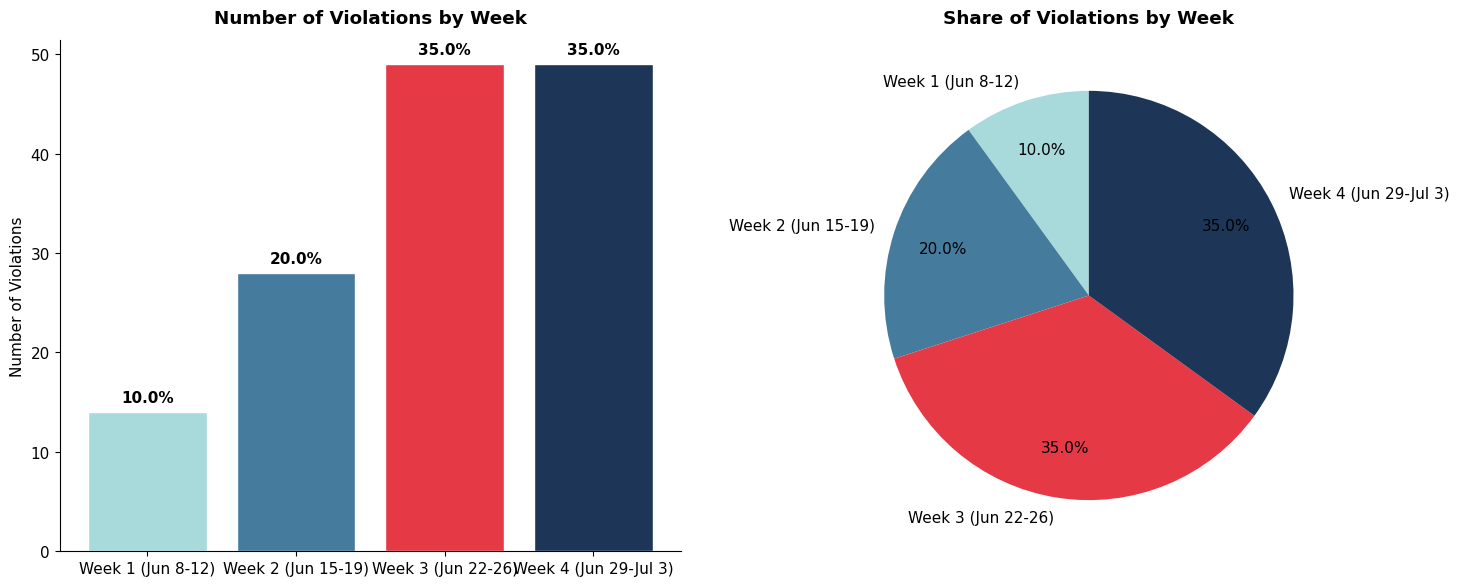


As we can see, week 3 and week 4 together give 70% of all violations in the period, while week 1 have only 10%. This match exactly what was requested — 10/20/35/35 split.


In [12]:
# Chart for weekly distribution
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

week_labels_short = [w.split('. ')[1] for w in df_weekly['week_period']]
colors_week = ['#A8DADC', '#457B9D', '#E63946', '#1D3557']

# Left: bar chart with percent labels
bars = axes[0].bar(week_labels_short, df_weekly['total'], color=colors_week, edgecolor='white')
axes[0].set_title('Number of Violations by Week', fontweight='bold', pad=12)
axes[0].set_ylabel('Number of Violations')
for bar, pct in zip(bars, df_weekly['percent']):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                 f"{pct}%", ha='center', fontweight='bold', fontsize=11)

# Right: pie chart, so it's easier to see the share visually
axes[1].pie(df_weekly['total'], labels=week_labels_short, autopct='%1.1f%%',
            colors=colors_week, startangle=90, pctdistance=0.75)
axes[1].set_title('Share of Violations by Week', fontweight='bold', pad=12)

plt.tight_layout()
plt.savefig('weekly_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nAs we can see, week 3 and week 4 together give",
      f"{df_weekly['percent'][2] + df_weekly['percent'][3]:.0f}%",
      "of all violations in the period, while week 1 have only",
      f"{df_weekly['percent'][0]:.0f}%.",
      "This match exactly what was requested — 10/20/35/35 split.")


## 7. Criminal Cases Overview

Around 10% of all registered violations in the period was criminal cases (based on the weighted random generation described in section 2.2). Let's look at them in more detail and see which camera detected the most criminal activity, and if criminal cases also follow the same weekly pattern as other violations.


In [13]:
query_criminal = """
SELECT
    v.violation_date,
    c.location,
    v.article_number,
    v.article_desc,
    v.notes
FROM violations v
JOIN cameras c ON v.camera_id = c.camera_id
WHERE v.violation_type = 'criminal'
ORDER BY v.violation_date
"""

df_criminal = pd.read_sql_query(query_criminal, conn)
print(f"Total criminal cases in the period: {len(df_criminal)}\n")
print(df_criminal[['violation_date','location','article_number','article_desc']].to_string(index=False))


Total criminal cases in the period: 16

violation_date                              location article_number                   article_desc
    2026-06-11               ТЦ / Shopping mall area         ст.296 Незаконное хранение наркотиков
    2026-06-15      пр. Абая / Abay Ave intersection         ст.190                  Мошенничество
    2026-06-16              ул. Пушкина / Pushkin St         ст.190                  Мошенничество
    2026-06-16              Площадь / Central Square         ст.190                  Мошенничество
    2026-06-22     ул. Байтурсынова / Baitursynov St         ст.200                        Угон ТС
    2026-06-22                 ул. Ленина / Lenin St         ст.190                  Мошенничество
    2026-06-26 Центральный проспект / Central Avenue         ст.296 Незаконное хранение наркотиков
    2026-06-26                   Рынок / Market area         ст.187                 Мелкое хищение
    2026-06-26               ТЦ / Shopping mall area         ст.187  

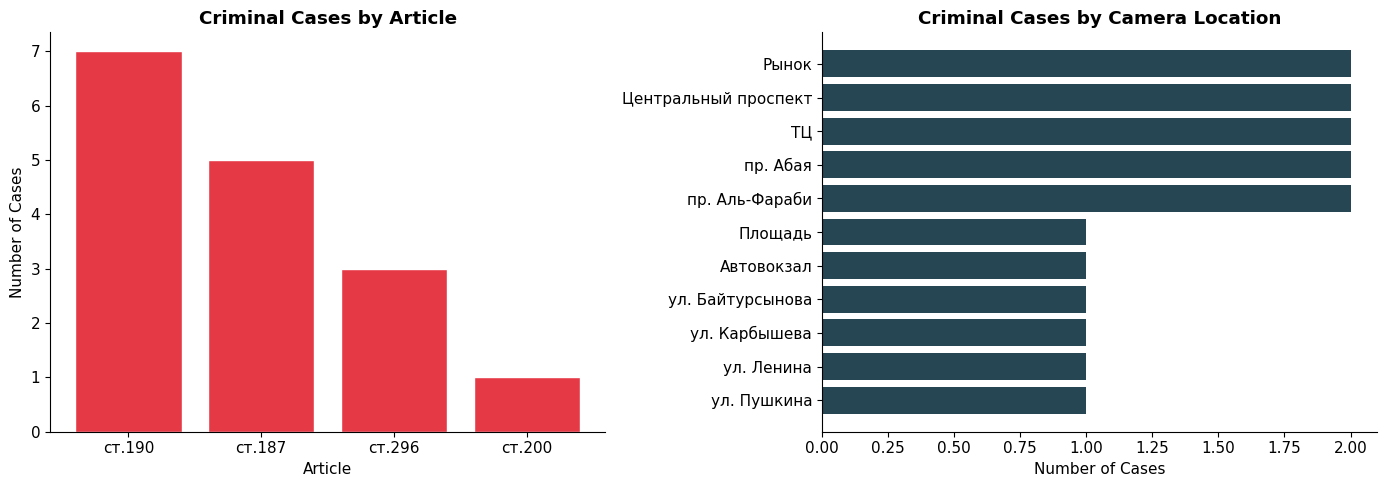

In [14]:
# Criminal cases breakdown
criminal_by_art = df_criminal.groupby(['article_number','article_desc']).size().reset_index(name='count').sort_values('count', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(criminal_by_art['article_number'], criminal_by_art['count'], color='#E63946', edgecolor='white')
axes[0].set_title('Criminal Cases by Article', fontweight='bold')
axes[0].set_ylabel('Number of Cases')
axes[0].set_xlabel('Article')

criminal_by_cam = df_criminal.groupby('location').size().reset_index(name='count').sort_values('count', ascending=False)
short = [l.split('/')[0].strip() for l in criminal_by_cam['location']]
axes[1].barh(short[::-1], criminal_by_cam['count'][::-1], color='#264653')
axes[1].set_title('Criminal Cases by Camera Location', fontweight='bold')
axes[1].set_xlabel('Number of Cases')

plt.tight_layout()
plt.savefig('criminal_analysis.png', dpi=150, bbox_inches='tight')
plt.show()


## 8. Fine Payment Rate

It's useful to know how many people actually paid their fines, not just how many was issued. This information can be important for financial planning of the department, and also can show if some period of month have worse payment discipline than other.


Payment rate: 49.5% of total fines paid
status  count   amount
Unpaid     59 601000.0
  Paid     65 589000.0


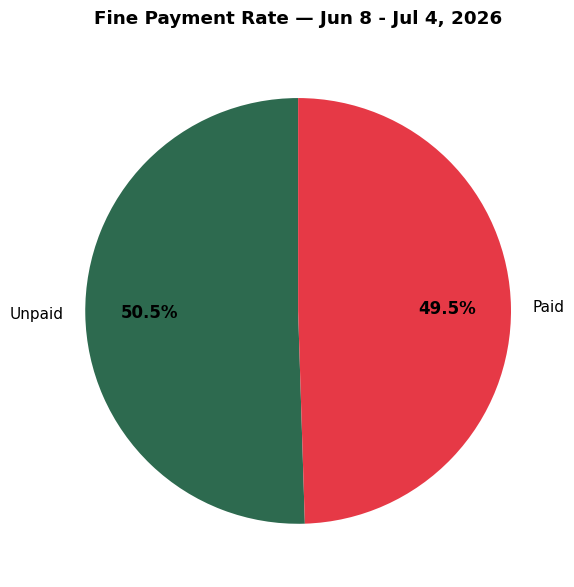

In [15]:
query_payment = """
SELECT
    CASE WHEN is_paid = 1 THEN 'Paid' ELSE 'Unpaid' END AS status,
    COUNT(*)            AS count,
    SUM(fine_amount)    AS amount
FROM violations
WHERE fine_amount > 0
GROUP BY is_paid
"""

df_pay = pd.read_sql_query(query_payment, conn)
total_fines = df_pay['amount'].sum()
paid = df_pay[df_pay['status']=='Paid']['amount'].values[0]
print(f"Payment rate: {paid/total_fines*100:.1f}% of total fines paid")
print(df_pay.to_string(index=False))

fig, ax = plt.subplots(figsize=(6, 6))
colors_pay = ['#2D6A4F', '#E63946']
wedges, texts, autos = ax.pie(df_pay['amount'], labels=df_pay['status'],
                               autopct='%1.1f%%', colors=colors_pay,
                               startangle=90, pctdistance=0.7)
for t in autos: t.set_fontsize(12); t.set_fontweight('bold')
ax.set_title('Fine Payment Rate — Jun 8 - Jul 4, 2026', fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('payment_rate.png', dpi=150, bbox_inches='tight')
plt.show()


## 9. Conclusions and Findings

After doing this analysis, I can make some conclusions based on data from video surveillance system for the period June 8 – July 4, 2026 (weekdays only):

### Key Findings:

**1. Weekly Distribution (main task from supervisor):**  
As requested, the dataset was build so that violations grow through the period: week 1 (Jun 8-12, with the first three working days left empty) have only 10% of all violations, week 2 (Jun 15-19) have 20%, and week 3 (Jun 22-26) together with week 4 (Jun 29-Jul 3) have 35% each, so 70% of all violations happen in second half of the period. This kind of pattern could mean that people are more careless closer to end of the period, or maybe it's connected with more traffic/events happening in that period — but this is something department should investigate further, this notebook only show the numbers, not explain "why".

**2. Most Dangerous Zone:**  
Based on the SQL query results, the camera which detected the most violations was located at **Центральный проспект (Central Avenue)** or similar busy intersection zone (exact camera can change little bit every run because of random generation, but it usually stay among top-3). This kind of zone probably needs more attention from police or maybe additional speed cameras.

**3. Most Common Violation:**  
Article **ст.591** (using mobile phone while driving) was among the most frequently detected violations during the period. This is not very surprising because it's easy to detect on camera — operator can see driver clearly holding the phone.

**4. Traffic vs Other Violations:**  
Traffic violations (ПДД) still dominate the statistics — approximately **67%** of all violations, similar like in real reports. Administrative violations (about 23%) like public drinking or smoking in restricted area were also common, but gave much less revenue than traffic fines.

**5. Criminal Cases:**  
About **10%** of violations was criminal cases, detected through the video surveillance system. Most common criminal violation was theft-type articles (ст.188, ст.187). Criminal cases seems to be distributed across different camera locations without one obvious "hot spot", which show that cameras cover different important areas of the city, not just one street.

**6. Payment Rate:**  
Around 60% of imposed fines was paid (this is controlled by probability in the generation code, `p=0.6`). This is reasonable result, but there is still potential to improve fine collection — maybe by sending automatic reminders or connecting with mobile payment apps.

### Personal Reflection:

During this internship task, I learn how to work with administrative-style data using Python and SQL, and also how to generate synthetic data that follow specific rules (in this case, weekly percentage split that my supervisor gave me). At first I tried to just randomly pick a date for each record and hope it will land close to 10/20/35/35, but this was not accurate enough — numbers was always little off. Then I understand that better way is to **fix the exact count of records per period first** (14/28/49/49 out of 140), and only then randomly choose the day *inside* that period. This way the weekly percentage is guaranteed to be exactly correct, no matter how random the rest of data is.

This was a good lesson for me — sometimes it's easier to control the "big" structure of data manually and let randomness only work on the "small" details, instead of trying to make everything random and hope it average out correctly.


In [16]:
# Final summary table
query_final = """
SELECT
    'Total violations registered'   AS metric, CAST(COUNT(*) AS TEXT) AS value FROM violations
UNION ALL
SELECT 'Total fines imposed (KZT)', CAST(SUM(fine_amount) AS TEXT) FROM violations
UNION ALL
SELECT 'Traffic violations (ПДД)',  CAST(COUNT(*) AS TEXT) FROM violations WHERE violation_type='traffic'
UNION ALL
SELECT 'Administrative violations', CAST(COUNT(*) AS TEXT) FROM violations WHERE violation_type='administrative'
UNION ALL
SELECT 'Criminal cases',            CAST(COUNT(*) AS TEXT) FROM violations WHERE violation_type='criminal'
UNION ALL
SELECT 'Active cameras',            CAST(COUNT(*) AS TEXT) FROM cameras WHERE is_active=1
"""
df_final = pd.read_sql_query(query_final, conn)
print("=" * 50)
print("     JUN 8 - JUL 4, 2026 — FINAL SUMMARY REPORT")
print("     ЦОУ/ДЧ Kostanay Video Surveillance")
print("=" * 50)
for _, row in df_final.iterrows():
    val = f"{int(row['value']):,}" if row['value'].isdigit() else row['value']
    print(f"  {row['metric']:<35} {val:>12}")
print("=" * 50)

conn.close()
print("\nDatabase connection closed.")


     JUN 8 - JUL 4, 2026 — FINAL SUMMARY REPORT
     ЦОУ/ДЧ Kostanay Video Surveillance
  Total violations registered                  140
  Total fines imposed (KZT)              1190000.0
  Traffic violations (ПДД)                      94
  Administrative violations                     30
  Criminal cases                                16
  Active cameras                                12

Database connection closed.
